# CNT-Al Composite — Prediction UI (Hardness-Calibrated)
### Upload the four files produced by the matching hardness-calibrated training notebook

All original prediction, batch, plotting, interactive, and sensitivity-analysis tasks are preserved.


---
## STEP 1 — Install & Import

In [ ]:
!pip install joblib scikit-learn ipywidgets -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import json, joblib, os, warnings
warnings.filterwarnings('ignore')

from scipy.stats import pearsonr, spearmanr

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 10

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

os.makedirs('ui_outputs', exist_ok=True)
print('✓ Libraries ready.  IN_COLAB =', IN_COLAB)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 24.5 MB/s eta 0:00:00
✓ Libraries ready.  IN_COLAB = True


---
## STEP 2 — Upload Model Files

In [ ]:
# ── Upload all 4 required files ───────────────────────────────────────────────
REQUIRED = ['best_model.pkl', 'scaler_X.pkl', 'scaler_Y.pkl', 'model_metadata.json']

if IN_COLAB:
    print('Please upload the following 4 files when the dialog opens:')
    for f in REQUIRED: print(f'  • {f}')
    print()
    uploaded = files.upload()
    print('\nUploaded:', list(uploaded.keys()))
else:
    # ← If running locally, set MODEL_DIR to the folder containing the 4 files
    MODEL_DIR = 'outputs'   # change if needed
    for f in REQUIRED:
        src = os.path.join(MODEL_DIR, f)
        if os.path.exists(src):
            import shutil; shutil.copy(src, f)
    print(f'Copied files from {MODEL_DIR}/')

# Verify all files are present
missing = [f for f in REQUIRED if not os.path.exists(f)]
if missing:
    raise FileNotFoundError(f'Missing files: {missing}\nPlease upload them.')
print('\n✓ All required files found:')
for f in REQUIRED:
    print(f'  {f:<30} {os.path.getsize(f)/1024:.1f} KB')

Please upload the following 4 files when the dialog opens:
  • best_model.pkl
  • scaler_X.pkl
  • scaler_Y.pkl
  • model_metadata.json



Saving best_model.pkl to best_model.pkl
Saving model_metadata.json to model_metadata.json
Saving scaler_X.pkl to scaler_X.pkl
Saving scaler_Y.pkl to scaler_Y.pkl

Uploaded: ['best_model.pkl', 'model_metadata.json', 'scaler_X.pkl', 'scaler_Y.pkl']

✓ All required files found:
  best_model.pkl                 1084.1 KB
  scaler_X.pkl                   0.8 KB
  scaler_Y.pkl                   0.7 KB
  model_metadata.json            1.9 KB


---
## STEP 3 — Load Model, Scalers & Metadata

In [ ]:
model    = joblib.load('best_model.pkl')
scaler_X = joblib.load('scaler_X.pkl')
scaler_Y = joblib.load('scaler_Y.pkl')

with open('model_metadata.json') as f:
    meta = json.load(f)

# Validate that the four uploaded files belong to the current training pipeline.
required_meta = {
    'feature_cols', 'target_cols', 'feature_ranges', 'model_name', 'cv_r2_avg',
    'scaler_X_mean', 'scaler_X_std', 'scaler_Y_mean', 'scaler_Y_std',
    'hardness_yield_factor'
}
missing_meta = sorted(required_meta.difference(meta))
if missing_meta:
    raise ValueError(f'model_metadata.json is missing required keys: {missing_meta}')

feat_cols   = list(meta['feature_cols'])
target_cols = list(meta['target_cols'])

expected_features = [
    'CNT_d_nm','CNT_l_nm','CNT_wt_pct','CNT_vol_frac',
    'Al_particle_size_um','Al_wt_pct','ISS_MPa','Sinter_T_K','Porosity_pct'
]
expected_targets = ['sigma_y_MPa','Hardness_GPa','sigma_UTS_MPa']

if feat_cols != expected_features:
    raise ValueError(
        'The uploaded model uses a different feature list/order.\n'
        f'Expected: {expected_features}\nFound: {feat_cols}'
    )
if target_cols != expected_targets:
    raise ValueError(
        'The uploaded model uses a different target list/order.\n'
        f'Expected: {expected_targets}\nFound: {target_cols}'
    )

# Convert JSON ranges to validated finite floats.
feat_ranges = {}
for col in feat_cols:
    if col not in meta['feature_ranges'] or len(meta['feature_ranges'][col]) != 2:
        raise ValueError(f'Invalid or missing feature range for {col}')
    lo, hi = map(float, meta['feature_ranges'][col])
    if not (np.isfinite(lo) and np.isfinite(hi) and lo < hi):
        raise ValueError(f'Invalid trained range for {col}: {[lo, hi]}')
    feat_ranges[col] = [lo, hi]

model_name   = str(meta['model_name'])
cv_r2        = float(meta['cv_r2_avg'])
uts_sy_ratio = float(meta.get('uts_sigma_y_ratio', 1.55))
hardness_yield_factor = float(meta['hardness_yield_factor'])
if not np.isfinite(hardness_yield_factor) or not (1.0 <= hardness_yield_factor <= 10.0):
    raise ValueError(f'Invalid hardness_yield_factor in metadata: {hardness_yield_factor}')

# Reconstruct scaler parameters for display and compatibility checks.
X_mean = np.asarray(meta['scaler_X_mean'], dtype=float)
X_std  = np.asarray(meta['scaler_X_std'], dtype=float)
Y_mean = np.asarray(meta['scaler_Y_mean'], dtype=float)
Y_std  = np.asarray(meta['scaler_Y_std'], dtype=float)

if len(X_mean) != len(feat_cols) or len(X_std) != len(feat_cols):
    raise ValueError('Feature scaler metadata length does not match feature_cols.')
if len(Y_mean) != len(target_cols) or len(Y_std) != len(target_cols):
    raise ValueError('Target scaler metadata length does not match target_cols.')
if hasattr(scaler_X, 'n_features_in_') and scaler_X.n_features_in_ != len(feat_cols):
    raise ValueError('scaler_X.pkl is incompatible with model_metadata.json.')
if hasattr(scaler_Y, 'n_features_in_') and scaler_Y.n_features_in_ != len(target_cols):
    raise ValueError('scaler_Y.pkl is incompatible with model_metadata.json.')

# One non-destructive prediction verifies that model + both scalers are mutually compatible.
_probe_x = np.asarray([X_mean], dtype=float)
_probe_y_scaled = np.asarray(model.predict(scaler_X.transform(_probe_x)))
if _probe_y_scaled.ndim == 1:
    _probe_y_scaled = _probe_y_scaled.reshape(1, -1)
if _probe_y_scaled.shape != (1, len(target_cols)):
    raise ValueError(
        f'Model output shape {_probe_y_scaled.shape} is incompatible with {len(target_cols)} targets.'
    )
_probe_y = scaler_Y.inverse_transform(_probe_y_scaled)
if not np.isfinite(_probe_y).all():
    raise ValueError('The uploaded model/scalers produced a non-finite compatibility-test prediction.')

# Composition relations used by the latest synthetic training data.
RHO_CNT, RHO_AL = 2.1, 2.7

def cnt_wt_to_vf(cnt_wt_pct: float) -> float:
    wc = float(cnt_wt_pct) / 100.0
    wa = 1.0 - wc
    den = wc / RHO_CNT + wa / RHO_AL
    return (wc / RHO_CNT) / den * 100.0 if den > 0 else np.nan

def cnt_vf_to_wt(cnt_vf_pct: float) -> float:
    vf = float(cnt_vf_pct) / 100.0
    den = vf * RHO_CNT + (1.0 - vf) * RHO_AL
    return vf * RHO_CNT / den * 100.0 if den > 0 else np.nan

def range_violations(values: dict):
    problems = []
    for col in feat_cols:
        v = float(values[col])
        lo, hi = feat_ranges[col]
        if not np.isfinite(v):
            problems.append(f'{col} is not finite')
        elif v < lo or v > hi:
            problems.append(f'{col}={v:.6g} outside [{lo:.6g}, {hi:.6g}]')
    return problems

print('═'*66)
print(f'  Model           : {model_name}')
print(f'  Synthetic CV R² : {cv_r2:.4f}')
print(f'  σ_UTS/σ_y ratio : {uts_sy_ratio:.3f}')
print(f'  H/σ_y factor    : {hardness_yield_factor:.3f}  (H_GPa = factor × σ_y_MPa / 1000)')
print('─'*66)
print(f'  Features ({len(feat_cols)}) — ACTUAL saved-model training ranges:')
for i, col in enumerate(feat_cols):
    lo, hi = feat_ranges[col]
    print(f'    {i+1:2d}. {col:<28} [{lo:.4g} – {hi:.4g}]')
print('─'*66)
print(f'  Targets ({len(target_cols)}): {target_cols}')
print('─'*66)
print('  ✓ Model, scalers, metadata, feature order and output shape are compatible.')
print('═'*66)

══════════════════════════════════════════════════════════════════
  Model           : MLP
  Synthetic CV R² : 0.9584
  σ_UTS/σ_y ratio : 1.581
  H/σ_y factor    : 4.273  (H_GPa = factor × σ_y_MPa / 1000)
──────────────────────────────────────────────────────────────────
  Features (9) — ACTUAL saved-model training ranges:
     1. CNT_d_nm                     [5.001 – 82.25]
     2. CNT_l_nm                     [100.1 – 4938]
     3. CNT_wt_pct                   [0.0007529 – 4.998]
     4. CNT_vol_frac                 [0.0009681 – 6.335]
     5. Al_particle_size_um          [0.101 – 55.66]
     6. Al_wt_pct                    [95 – 100]
     7. ISS_MPa                      [5.009 – 150]
     8. Sinter_T_K                   [534.8 – 1050]
     9. Porosity_pct                 [0.0001106 – 3.225]
──────────────────────────────────────────────────────────────────
  Targets (3): ['sigma_y_MPa', 'Hardness_GPa', 'sigma_UTS_MPa']
────────────────────────────────────────────────────────────────

In [ ]:
# ── Print normalisation parameters (for audit / reproducibility) ─────────────
print('FEATURE NORMALISATION PARAMETERS (StandardScaler):')
print(f"{'Feature':<30} {'Mean':>12} {'Std':>12}")
print('─'*56)
for col, mu, sd in zip(feat_cols, X_mean, X_std):
    print(f'{col:<30} {mu:>12.4f} {sd:>12.4f}')

print('\nTARGET NORMALISATION PARAMETERS (StandardScaler):')
print(f"{'Target':<30} {'Mean':>12} {'Std':>12}")
print('─'*56)
for col, mu, sd in zip(target_cols, Y_mean, Y_std):
    print(f'{col:<30} {mu:>12.4f} {sd:>12.4f}')

# Save normalisation table as CSV for paper
norm_df = pd.DataFrame({
    'Parameter': feat_cols + target_cols,
    'Type':      ['Feature']*len(feat_cols) + ['Target']*len(target_cols),
    'Mean':      list(X_mean) + list(Y_mean),
    'Std':       list(X_std)  + list(Y_std),
})
norm_df.to_csv('ui_outputs/normalisation_parameters.csv', index=False)
print('\n✓ Saved ui_outputs/normalisation_parameters.csv')

FEATURE NORMALISATION PARAMETERS (StandardScaler):
Feature                                Mean          Std
────────────────────────────────────────────────────────
CNT_d_nm                            25.6259      12.4579
CNT_l_nm                          1275.0280     800.1823
CNT_wt_pct                           2.3058       1.3211
CNT_vol_frac                         2.9390       1.6756
Al_particle_size_um                 14.5708       9.1870
Al_wt_pct                           97.6942       1.3211
ISS_MPa                             86.8391      39.0366
Sinter_T_K                         835.0567      80.6034
Porosity_pct                         0.8807       0.5768

TARGET NORMALISATION PARAMETERS (StandardScaler):
Target                                 Mean          Std
────────────────────────────────────────────────────────
sigma_y_MPa                        166.8422      43.9019
Hardness_GPa                         0.7312       0.1948
sigma_UTS_MPa                      249.5325

---
## STEP 4 — Core Prediction Function

In [ ]:
def _predict_array(x_raw: np.ndarray) -> np.ndarray:
    x_raw = np.asarray(x_raw, dtype=float)
    if x_raw.ndim != 2 or x_raw.shape[1] != len(feat_cols):
        raise ValueError(f'Expected input shape (n, {len(feat_cols)}); received {x_raw.shape}.')
    if not np.isfinite(x_raw).all():
        raise ValueError('All prediction inputs must be finite numeric values.')
    y_s = np.asarray(model.predict(scaler_X.transform(x_raw)))
    if y_s.ndim == 1:
        y_s = y_s.reshape(1, -1)
    if y_s.shape[1] != len(target_cols):
        raise ValueError(f'Model returned {y_s.shape[1]} outputs; expected {len(target_cols)}.')
    return scaler_Y.inverse_transform(y_s)


def predict(input_dict: dict, warn_range: bool = True) -> dict:
    """Predict σ_y, hardness and σ_UTS for one sample."""
    missing = [col for col in feat_cols if col not in input_dict]
    if missing:
        raise ValueError(f'Missing feature(s): {missing}')

    clean = {col: float(input_dict[col]) for col in feat_cols}
    if warn_range:
        for msg in range_violations(clean):
            print(f'  ⚠  {msg}')

    y_out = _predict_array([[clean[c] for c in feat_cols]])[0]
    pred = {t: float(y_out[j]) for j, t in enumerate(target_cols)}
    sy, h, uts = pred['sigma_y_MPa'], pred['Hardness_GPa'], pred['sigma_UTS_MPa']

    return {
        'sigma_y_MPa':     round(sy, 2),
        'Hardness_GPa':    round(h, 4),
        'sigma_UTS_MPa':   round(uts, 2),
        'UTS_YS_ratio':    round(uts / sy, 3) if sy > 0 else None,
        'Tabor_check_MPa': round(h * 1000.0 / hardness_yield_factor, 2),
        'Hardness_YS_check_MPa': round(h * 1000.0 / hardness_yield_factor, 2),
    }


def predict_batch(df_in: pd.DataFrame, warn_range: bool = True) -> pd.DataFrame:
    """Predict for a DataFrame containing the nine model input columns."""
    missing = [c for c in feat_cols if c not in df_in.columns]
    if missing:
        raise ValueError(f'Batch input is missing feature column(s): {missing}')

    X_df = df_in[feat_cols].apply(pd.to_numeric, errors='coerce')
    bad_rows = X_df.index[~np.isfinite(X_df.to_numpy()).all(axis=1)].tolist()
    if bad_rows:
        raise ValueError(f'Batch input contains missing/non-numeric values in row(s): {bad_rows}')

    if warn_range:
        counts = {}
        for col in feat_cols:
            lo, hi = feat_ranges[col]
            counts[col] = int(((X_df[col] < lo) | (X_df[col] > hi)).sum())
        counts = {k: v for k, v in counts.items() if v}
        if counts:
            print('⚠ Batch rows outside actual saved-model ranges:')
            for col, n in counts.items():
                lo, hi = feat_ranges[col]
                print(f'  {col}: {n} row(s), trained range [{lo:.6g}, {hi:.6g}]')

    Y = _predict_array(X_df.to_numpy())
    out = df_in.copy()
    for j, t in enumerate(target_cols):
        out[t] = np.round(Y[:, j], 3)
    return out


print('✓ predict() and predict_batch() ready.')

✓ predict() and predict_batch() ready.


---
## STEP 5 — Manual Single-Sample Prediction

**Edit the nine values below, then run the cell.**

The valid numerical limits are read directly from the uploaded `model_metadata.json` and printed in **STEP 3**. Those are the actual ranges represented in the saved model, and they supersede the older broad design limits previously written in this notebook.

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║   EDIT THESE 9 VALUES, THEN RUN THE CELL                ║
# ╚══════════════════════════════════════════════════════════╝

_default_cnt_wt = 1.5
my_sample = {
    'CNT_d_nm':             20.0,                    # CNT diameter          (nm)
    'CNT_l_nm':           4500.0,                    # CNT length            (nm)
    'CNT_wt_pct':   _default_cnt_wt,                 # CNT weight %          (wt%)
    'CNT_vol_frac': cnt_wt_to_vf(_default_cnt_wt),   # density-consistent    (vol%)
    'Al_particle_size_um':   5.0,                    # Al powder size        (μm)
    'Al_wt_pct':    100.0 - _default_cnt_wt,         # mass-consistent       (wt%)
    'ISS_MPa':              50.0,                    # Interfacial shear str (MPa)
    'Sinter_T_K':          873.0,                    # Sintering temperature (K)
    'Porosity_pct':          0.5,                    # Porosity              (%)
}

# ── Prediction ────────────────────────────────────────────────────────────────
res = predict(my_sample)

# ── Formatted output ──────────────────────────────────────────────────────────
W = 54
print('╔' + '═'*W + '╗')
print(f'║  {"CNT-Al Composite — Property Prediction":^{W-2}}║')
print(f'║  {f"Model: {model_name}  |  Synthetic CV R²={cv_r2:.4f}":^{W-2}}║')
print('╠' + '─'*W + '╣')
print(f'║  {"INPUT":^{W-2}}║')
print('╠' + '─'*W + '╣')
unit_map = {'CNT_d_nm':'nm','CNT_l_nm':'nm','CNT_wt_pct':'wt%','CNT_vol_frac':'vol%',
            'Al_particle_size_um':'μm','Al_wt_pct':'wt%','ISS_MPa':'MPa',
            'Sinter_T_K':'K','Porosity_pct':'%'}
for k, v in my_sample.items():
    print(f'║  {k:<28} {v:>10.4g}  {unit_map.get(k,""):<8}    ║')
print('╠' + '═'*W + '╣')
print(f'║  {"OUTPUT":^{W-2}}║')
print('╠' + '─'*W + '╣')
print(f'║  {"Yield Strength  σ_y":<28} {res["sigma_y_MPa"]:>10.2f}  MPa        ║')
print(f'║  {"Hardness":<28} {res["Hardness_GPa"]:>10.4f}  GPa        ║')
print(f'║  {"Ultimate Strength  σ_UTS":<28} {res["sigma_UTS_MPa"]:>10.2f}  MPa        ║')
print('╠' + '─'*W + '╣')
print(f'║  {"UTS / YS ratio":<28} {res["UTS_YS_ratio"]:>10.3f}  (typ 1.2–1.95)║')
print(f'║  {"H-derived yield strength":<28} {res["Hardness_YS_check_MPa"]:>10.2f}  MPa ≈ σ_y   ║')
print('╚' + '═'*W + '╝')

╔══════════════════════════════════════════════════════╗
║         CNT-Al Composite — Property Prediction       ║
║         Model: MLP  |  Synthetic CV R²=0.9584        ║
╠──────────────────────────────────────────────────────╣
║                         INPUT                        ║
╠──────────────────────────────────────────────────────╣
║  CNT_d_nm                             20  nm          ║
║  CNT_l_nm                           4500  nm          ║
║  CNT_wt_pct                          1.5  wt%         ║
║  CNT_vol_frac                       1.92  vol%        ║
║  Al_particle_size_um                   5  μm          ║
║  Al_wt_pct                          98.5  wt%         ║
║  ISS_MPa                              50  MPa         ║
║  Sinter_T_K                          873  K           ║
║  Porosity_pct                        0.5  %           ║
╠══════════════════════════════════════════════════════╣
║                         OUTPUT                       ║
╠─────────────────────

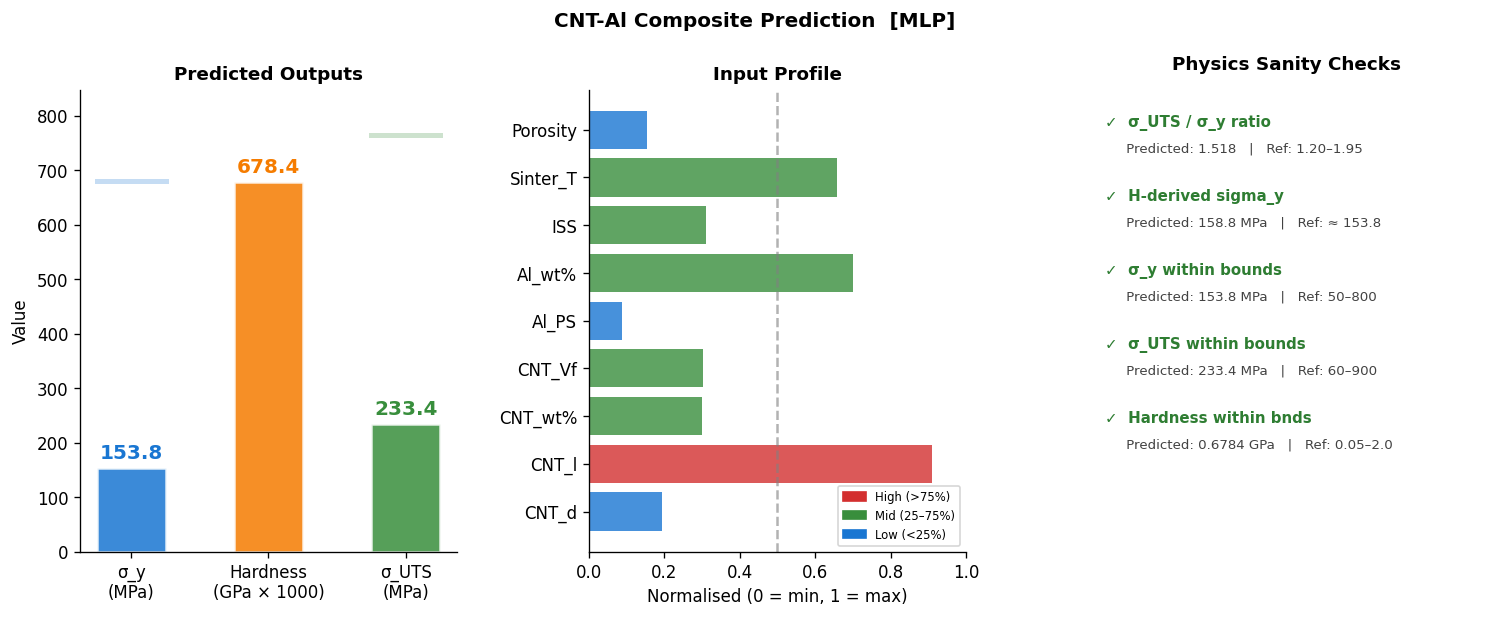

✓ Saved ui_outputs/prediction_result.png


In [ ]:
# ── Visual result card ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ① Predicted outputs — gauge bars
ax1 = fig.add_subplot(gs[0])
labels   = ['σ_y\n(MPa)', 'Hardness\n(GPa × 1000)', 'σ_UTS\n(MPa)']
values   = [res['sigma_y_MPa'], res['Hardness_GPa']*1000, res['sigma_UTS_MPa']]
ref_ranges = [(50,800), (50,2000), (60,900)]
colors_b = ['#1976D2', '#F57C00', '#388E3C']
bars = ax1.bar(labels, values, color=colors_b, alpha=0.85, width=0.5, edgecolor='white', linewidth=1.5)
for bar, val, (lo, hi), c in zip(bars, values, ref_ranges, colors_b):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(values)*0.015,
             f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=12, color=c)
    # reference range line
    ax1.plot([bar.get_x(), bar.get_x()+bar.get_width()], [hi*0.85, hi*0.85],
             color=c, alpha=0.25, linewidth=3)
ax1.set_ylim(0, max(values)*1.25)
ax1.set_title('Predicted Outputs', fontweight='bold', fontsize=11)
ax1.set_ylabel('Value')
ax1.spines[['top','right']].set_visible(False)

# ② Normalised input profile
ax2 = fig.add_subplot(gs[1])
normed = [(my_sample[c] - feat_ranges[c][0]) / max(feat_ranges[c][1]-feat_ranges[c][0], 1e-9)
          for c in feat_cols]
short  = ['CNT_d','CNT_l','CNT_wt%','CNT_Vf','Al_PS','Al_wt%','ISS','Sinter_T','Porosity']
bar_colors = ['#d32f2f' if v > 0.75 else '#1976D2' if v < 0.25 else '#388E3C' for v in normed]
ax2.barh(short, normed, color=bar_colors, alpha=0.80)
ax2.axvline(0.5, color='grey', linestyle='--', alpha=0.6, label='Mid-range')
ax2.set_xlim(0, 1)
ax2.set_xlabel('Normalised (0 = min, 1 = max)')
ax2.set_title('Input Profile', fontweight='bold', fontsize=11)
ax2.legend(fontsize=8)
ax2.spines[['top','right']].set_visible(False)
patches = [mpatches.Patch(color='#d32f2f', label='High (>75%)'),
           mpatches.Patch(color='#388E3C', label='Mid (25–75%)'),
           mpatches.Patch(color='#1976D2', label='Low (<25%)')]
ax2.legend(handles=patches, fontsize=7, loc='lower right')

# ③ Physics check summary
ax3 = fig.add_subplot(gs[2])
ax3.axis('off')
checks_text = [
    ('σ_UTS / σ_y ratio',   f"{res['UTS_YS_ratio']:.3f}",  '1.20–1.95', 1.20<=res['UTS_YS_ratio']<=1.95),
    ('H-derived sigma_y',      f"{res['Hardness_YS_check_MPa']:.1f} MPa", f"≈ {res['sigma_y_MPa']:.1f}",
     abs(res['Hardness_YS_check_MPa']-res['sigma_y_MPa'])/max(res['sigma_y_MPa'],1) < 0.30),
    ('σ_y within bounds',   f"{res['sigma_y_MPa']:.1f} MPa",  '50–800',   50<=res['sigma_y_MPa']<=800),
    ('σ_UTS within bounds', f"{res['sigma_UTS_MPa']:.1f} MPa",'60–900',   60<=res['sigma_UTS_MPa']<=900),
    ('Hardness within bnds',f"{res['Hardness_GPa']:.4f} GPa", '0.05–2.0', 0.05<=res['Hardness_GPa']<=2.0),
]
ax3.set_title('Physics Sanity Checks', fontweight='bold', fontsize=11, pad=12)
y_pos = 0.92
for label, val, ref, ok in checks_text:
    icon = '✓' if ok else '⚠'
    color = '#2e7d32' if ok else '#c62828'
    ax3.text(0.02, y_pos, f'{icon}  {label}', transform=ax3.transAxes,
             fontsize=9, color=color, fontweight='bold')
    ax3.text(0.02, y_pos-0.055, f'     Predicted: {val}   |   Ref: {ref}',
             transform=ax3.transAxes, fontsize=8, color='#424242')
    y_pos -= 0.16

plt.suptitle(f'CNT-Al Composite Prediction  [{model_name}]',
             fontsize=12, fontweight='bold', y=1.01)
plt.savefig('ui_outputs/prediction_result.png', bbox_inches='tight')
plt.show()
print('✓ Saved ui_outputs/prediction_result.png')

---
## STEP 6 — Interactive Slider UI

In [ ]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    style_w  = {'description_width': '210px'}
    layout_w = widgets.Layout(width='500px')

    # Build numeric text inputs (allows true blank) instead of sliders
    input_cfg = {
        'CNT_d_nm':            dict(description='CNT Diameter (nm)',      value=my_sample['CNT_d_nm']),
        'CNT_l_nm':            dict(description='CNT Length (nm)',        value=my_sample['CNT_l_nm']),
        'CNT_wt_pct':          dict(description='CNT wt%',                value=my_sample['CNT_wt_pct']),
        'CNT_vol_frac':        dict(description='CNT Vol Frac (vol%)',    value=my_sample['CNT_vol_frac']),
        'Al_particle_size_um': dict(description='Al Particle Size (μm)',  value=my_sample['Al_particle_size_um']),
        'Al_wt_pct':           dict(description='Al wt%',                 value=my_sample['Al_wt_pct']),
        'ISS_MPa':             dict(description='ISS (MPa)',              value=my_sample['ISS_MPa']),
        'Sinter_T_K':          dict(description='Sintering Temp (K)',     value=my_sample['Sinter_T_K']),
        'Porosity_pct':        dict(description='Porosity (%)',           value=my_sample['Porosity_pct']),
    }

    # Text boxes allow blank; parse later
    inputs = {
        k: widgets.Text(
            value=str(v['value']),
            description=v['description'],
            style=style_w,
            layout=layout_w,
            placeholder='leave blank to use mean'
        )
        for k, v in input_cfg.items()
    }

    # Output labels
    out_sy    = widgets.FloatText(description='σ_y  (MPa)',    disabled=True, layout=widgets.Layout(width='280px'), style={'description_width':'150px'})
    out_h     = widgets.FloatText(description='Hardness (GPa)', disabled=True, layout=widgets.Layout(width='280px'), style={'description_width':'150px'})
    out_uts   = widgets.FloatText(description='σ_UTS (MPa)',   disabled=True, layout=widgets.Layout(width='280px'), style={'description_width':'150px'})
    out_ratio = widgets.FloatText(description='UTS/YS ratio',  disabled=True, layout=widgets.Layout(width='280px'), style={'description_width':'150px'})
    out_tabor = widgets.FloatText(description='H-derived σ_y (MPa)',  disabled=True, layout=widgets.Layout(width='280px'), style={'description_width':'150px'})
    warn_out  = widgets.Output()

    # Mean map from previously loaded metadata/scaler params
    mean_map = {c: float(m) for c, m in zip(feat_cols, X_mean)}

    def _safe_parse(txt):
        s = (txt or '').strip()
        if s == '':
            return None
        try:
            return float(s)
        except ValueError:
            return 'INVALID'

    def predict_allow_blank(input_dict: dict, warn_range: bool = True):
        """
        Blank value -> impute with feature mean from X_mean.
        Invalid non-numeric text raises ValueError.
        """
        x_vals = []
        used_mean = []

        for col in feat_cols:
            v = input_dict.get(col, None)

            if v == 'INVALID':
                raise ValueError(f'Invalid numeric input for {col}')

            if v is None or (isinstance(v, float) and np.isnan(v)):
                v_eff = mean_map[col]     # mean imputation
                used_mean.append(col)
            else:
                v_eff = float(v)
                if warn_range:
                    lo, hi = feat_ranges[col]
                    if v_eff < lo or v_eff > hi:
                        print(f'  ⚠  {col} = {v_eff:.3g} is outside the actual saved-model range [{lo:.3g}, {hi:.3g}]')

            x_vals.append(v_eff)

        x_raw = np.array([x_vals], dtype=float)
        x_s   = scaler_X.transform(x_raw)
        y_s   = model.predict(x_s)
        y_out = scaler_Y.inverse_transform(y_s)[0]

        sy  = float(y_out[0])
        h   = float(y_out[1])
        uts = float(y_out[2])

        result = {
            'sigma_y_MPa':     round(sy, 2),
            'Hardness_GPa':    round(h, 4),
            'sigma_UTS_MPa':   round(uts, 2),
            'UTS_YS_ratio':    round(uts / sy, 3) if sy > 0 else None,
            'Tabor_check_MPa': round(h * 1000.0 / hardness_yield_factor, 2),
            'Hardness_YS_check_MPa': round(h * 1000.0 / hardness_yield_factor, 2),
            'used_mean_for':   used_mean
        }
        return result

    def on_input_change(_):
        raw = {k: _safe_parse(w.value) for k, w in inputs.items()}

        with warn_out:
            clear_output(wait=True)
            try:
                r = predict_allow_blank(raw, warn_range=True)

                if len(r['used_mean_for']) > 0:
                    print('ℹ Blank fields imputed with feature means:')
                    for c in r['used_mean_for']:
                        print(f'   - {c}: {mean_map[c]:.4f}')

                out_sy.value    = r['sigma_y_MPa']
                out_h.value     = r['Hardness_GPa']
                out_uts.value   = r['sigma_UTS_MPa']
                out_ratio.value = r['UTS_YS_ratio']
                out_tabor.value = r['Hardness_YS_check_MPa']

            except Exception as e:
                print(f'⚠ {e}')

    # Observe changes
    for w in inputs.values():
        w.observe(on_input_change, names='value')

    header = widgets.HTML(
        f'<h2 style="color:#1565C0;margin-bottom:4px">🔬 CNT-Al Property Predictor</h2>'
        f'<p style="color:#555;margin-top:0">Model: <b>{model_name}</b> '
        f'| Synthetic 5-Fold CV R² = <b>{cv_r2:.4f}</b></p>'
        f'<p style="color:#777;font-size:12px">'
        f'Leave a field blank → mean imputation is used for prediction (field remains blank).</p>'
    )
    divider = widgets.HTML('<hr style="border:1px solid #ccc;margin:8px 0">')
    out_header = widgets.HTML('<b style="color:#2e7d32;font-size:13px">▼ Predicted Outputs</b>')
    in_header  = widgets.HTML('<b style="color:#1565C0;font-size:13px">▼ Input Parameters</b>')

    left_panel  = widgets.VBox([in_header] + list(inputs.values()))
    right_panel = widgets.VBox([
        out_header, divider,
        out_sy, out_h, out_uts,
        widgets.HTML('<hr style="border:1px dashed #aaa;margin:6px 0">'),
        out_ratio, out_tabor,
        warn_out
    ])

    panel = widgets.VBox([
        header,
        widgets.HBox([left_panel, widgets.HTML('&nbsp;'*4), right_panel])
    ])

    on_input_change(None)  # initial prediction
    display(panel)

except Exception as e:
    print(f'ipywidgets not available ({e}).\nUse the manual cell in STEP 5 instead.')

---
## STEP 7 — Batch Prediction from CSV Upload

In [ ]:
# ── Option A: Upload a CSV with 9 input columns ───────────────────────────────
# The CSV must contain exactly these columns (any order):
# CNT_d_nm, CNT_l_nm, CNT_wt_pct, CNT_vol_frac, Al_particle_size_um,
# Al_wt_pct, ISS_MPa, Sinter_T_K, Porosity_pct
#
# ── Option B: Edit the sample rows below ─────────────────────────────────────

USE_UPLOAD = False   # set True to upload a CSV; False to use the rows below

if USE_UPLOAD and IN_COLAB:
    print('Upload your batch CSV...')
    up = files.upload()
    batch_df = pd.read_csv(list(up.keys())[0])
    print(f'Loaded {len(batch_df)} rows from CSV.')
else:
    # The built-in examples remain inside the latest saved model's actual ranges.
    _batch_specs = [
        # d_nm, l_nm, wt%, Al_PS, ISS, T_K, Porosity
        (10,  4000, 1.00,  5,  60,  873, 0.5),
        (20,  3000, 1.50,  5,  50,  873, 0.5),
        (50,  2000, 2.00, 10,  40,  900, 1.0),
        (70,   700, 3.00, 20,  30,  700, 2.0),
        (12,  4500, 0.50,  2,  80,  950, 0.2),
        (15,  4000, 2.50,  7,  70,  825, 0.8),
        (30,  3500, 0.25, 15,  20,  580, 1.5),
        (9,   4800, 1.00,  3, 100, 1000, 0.1),
    ]
    batch_df = pd.DataFrame([
        dict(
            CNT_d_nm=d, CNT_l_nm=l, CNT_wt_pct=wt,
            CNT_vol_frac=cnt_wt_to_vf(wt),
            Al_particle_size_um=ps, Al_wt_pct=100.0-wt,
            ISS_MPa=iss, Sinter_T_K=temp, Porosity_pct=por
        )
        for d, l, wt, ps, iss, temp, por in _batch_specs
    ])

# ── Run batch prediction ──────────────────────────────────────────────────────
batch_results = predict_batch(batch_df, warn_range=True)
batch_results['UTS_YS_ratio'] = (batch_results['sigma_UTS_MPa'] / batch_results['sigma_y_MPa']).round(3)
batch_results['Hardness_implied_sigma_y_MPa'] = (batch_results['Hardness_GPa'] * 1000.0 / hardness_yield_factor).round(2)

display_cols = ['CNT_d_nm','CNT_l_nm','CNT_wt_pct','ISS_MPa','Sinter_T_K','Porosity_pct',
                'sigma_y_MPa','Hardness_GPa','sigma_UTS_MPa','UTS_YS_ratio']
print(f'Batch predictions ({len(batch_results)} samples):')
print(batch_results[display_cols].to_string(index=True))

batch_results.to_csv('ui_outputs/batch_predictions.csv', index=False)
print('\n✓ Saved ui_outputs/batch_predictions.csv')

Batch predictions (8 samples):
   CNT_d_nm  CNT_l_nm  CNT_wt_pct  ISS_MPa  Sinter_T_K  Porosity_pct  sigma_y_MPa  Hardness_GPa  sigma_UTS_MPa  UTS_YS_ratio
0        10      4000        1.00       60         873           0.5      134.965         0.595        205.310         1.521
1        20      3000        1.50       50         873           0.5      151.227         0.663        223.642         1.479
2        50      2000        2.00       40         900           1.0      155.794         0.675        224.134         1.439
3        70       700        3.00       30         700           2.0      160.510         0.705        218.739         1.363
4        12      4500        0.50       80         950           0.2      124.948         0.551        194.852         1.559
5        15      4000        2.50       70         825           0.8      190.093         0.827        290.548         1.528
6        30      3500        0.25       20         580           1.5       73.491         0.32

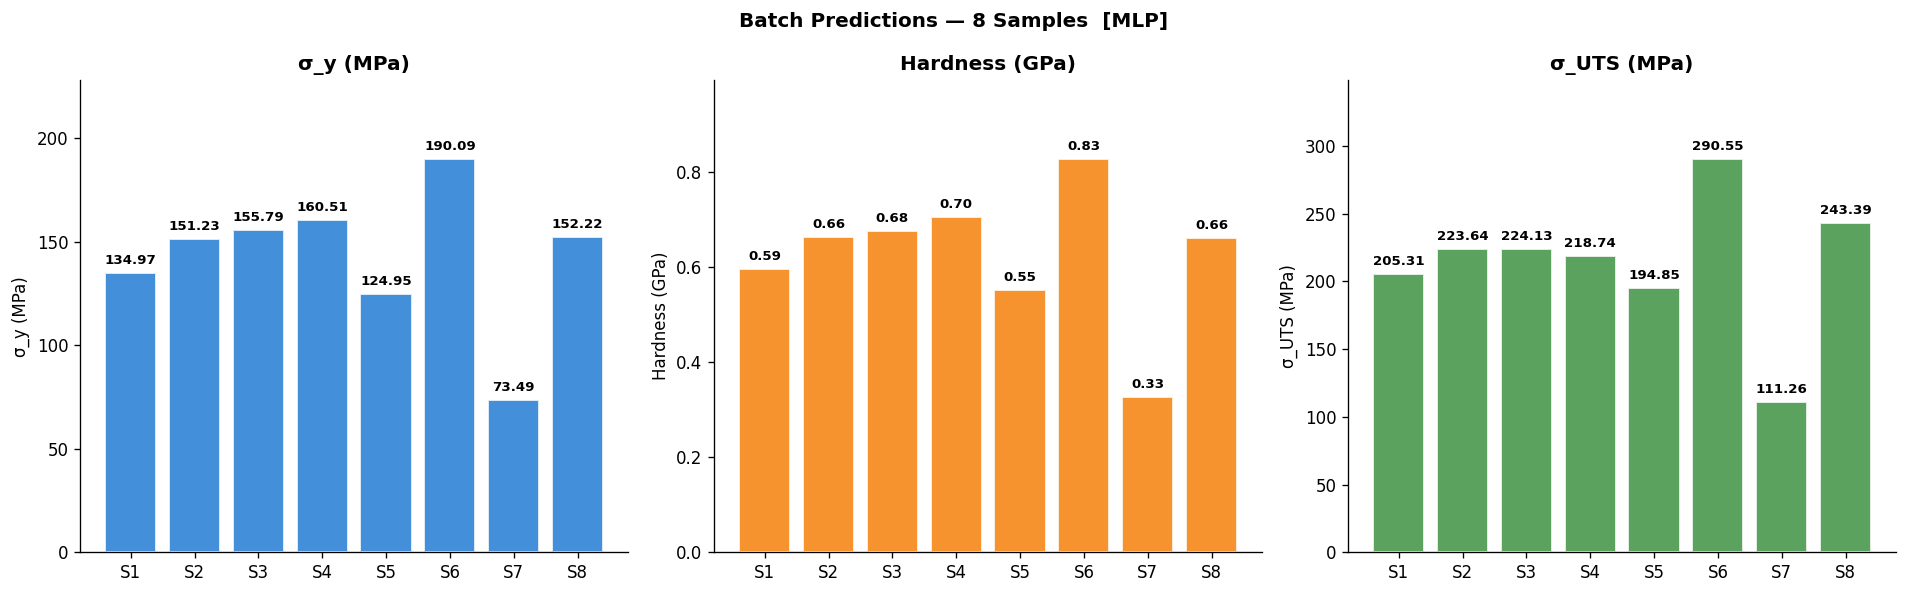

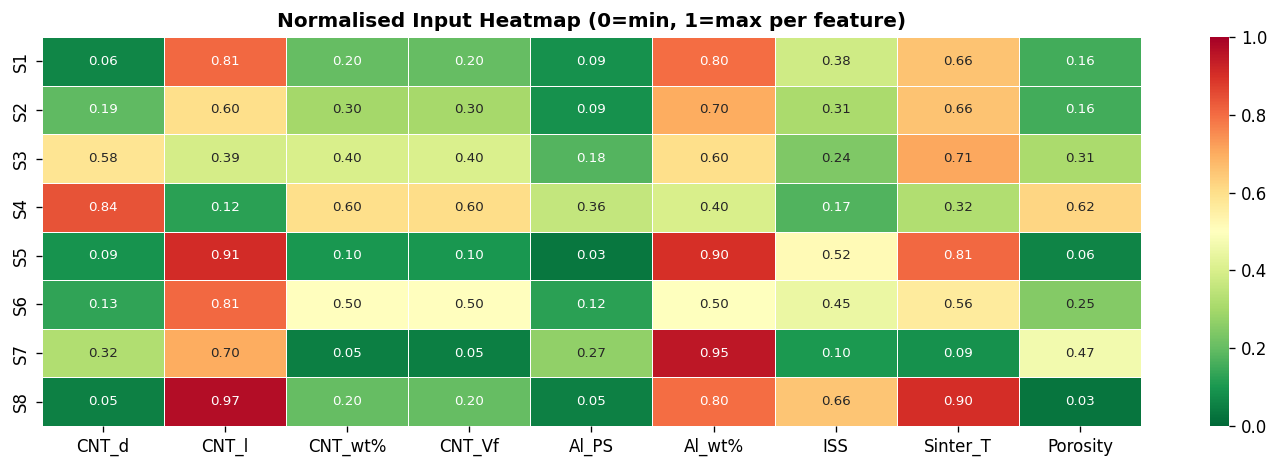

In [ ]:
# ── Batch results visualisation ───────────────────────────────────────────────
n_samples = len(batch_results)
sample_labels = [f'S{i+1}' for i in range(n_samples)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
target_info = [
    ('sigma_y_MPa',   'σ_y (MPa)',    '#1976D2'),
    ('Hardness_GPa',  'Hardness (GPa)','#F57C00'),
    ('sigma_UTS_MPa', 'σ_UTS (MPa)',  '#388E3C'),
]
for ax, (col, label, color) in zip(axes, target_info):
    vals = batch_results[col].values
    bars = ax.bar(sample_labels, vals, color=color, alpha=0.82, edgecolor='white', linewidth=1.2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.015,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(label, fontweight='bold')
    ax.set_ylim(0, max(vals)*1.20)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle(f'Batch Predictions — {n_samples} Samples  [{model_name}]',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('ui_outputs/batch_predictions_plot.png', bbox_inches='tight')
plt.show()

# Heatmap of batch inputs
norm_inp = batch_df[feat_cols].copy()
for col in feat_cols:
    lo, hi = feat_ranges[col]
    norm_inp[col] = (norm_inp[col] - lo) / max(hi - lo, 1e-9)
norm_inp.index = sample_labels

fig, ax = plt.subplots(figsize=(12, 4))
short = ['CNT_d','CNT_l','CNT_wt%','CNT_Vf','Al_PS','Al_wt%','ISS','Sinter_T','Porosity']
sns_data = norm_inp.copy(); sns_data.columns = short
import seaborn as sns
sns.heatmap(sns_data, annot=True, fmt='.2f', cmap='RdYlGn_r', vmin=0, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size':8})
ax.set_title('Normalised Input Heatmap (0=min, 1=max per feature)', fontweight='bold')
plt.tight_layout()
plt.savefig('ui_outputs/batch_input_heatmap.png', bbox_inches='tight')
plt.show()

---
## STEP 8 — Sensitivity Analysis (Each Input vs Each Output)

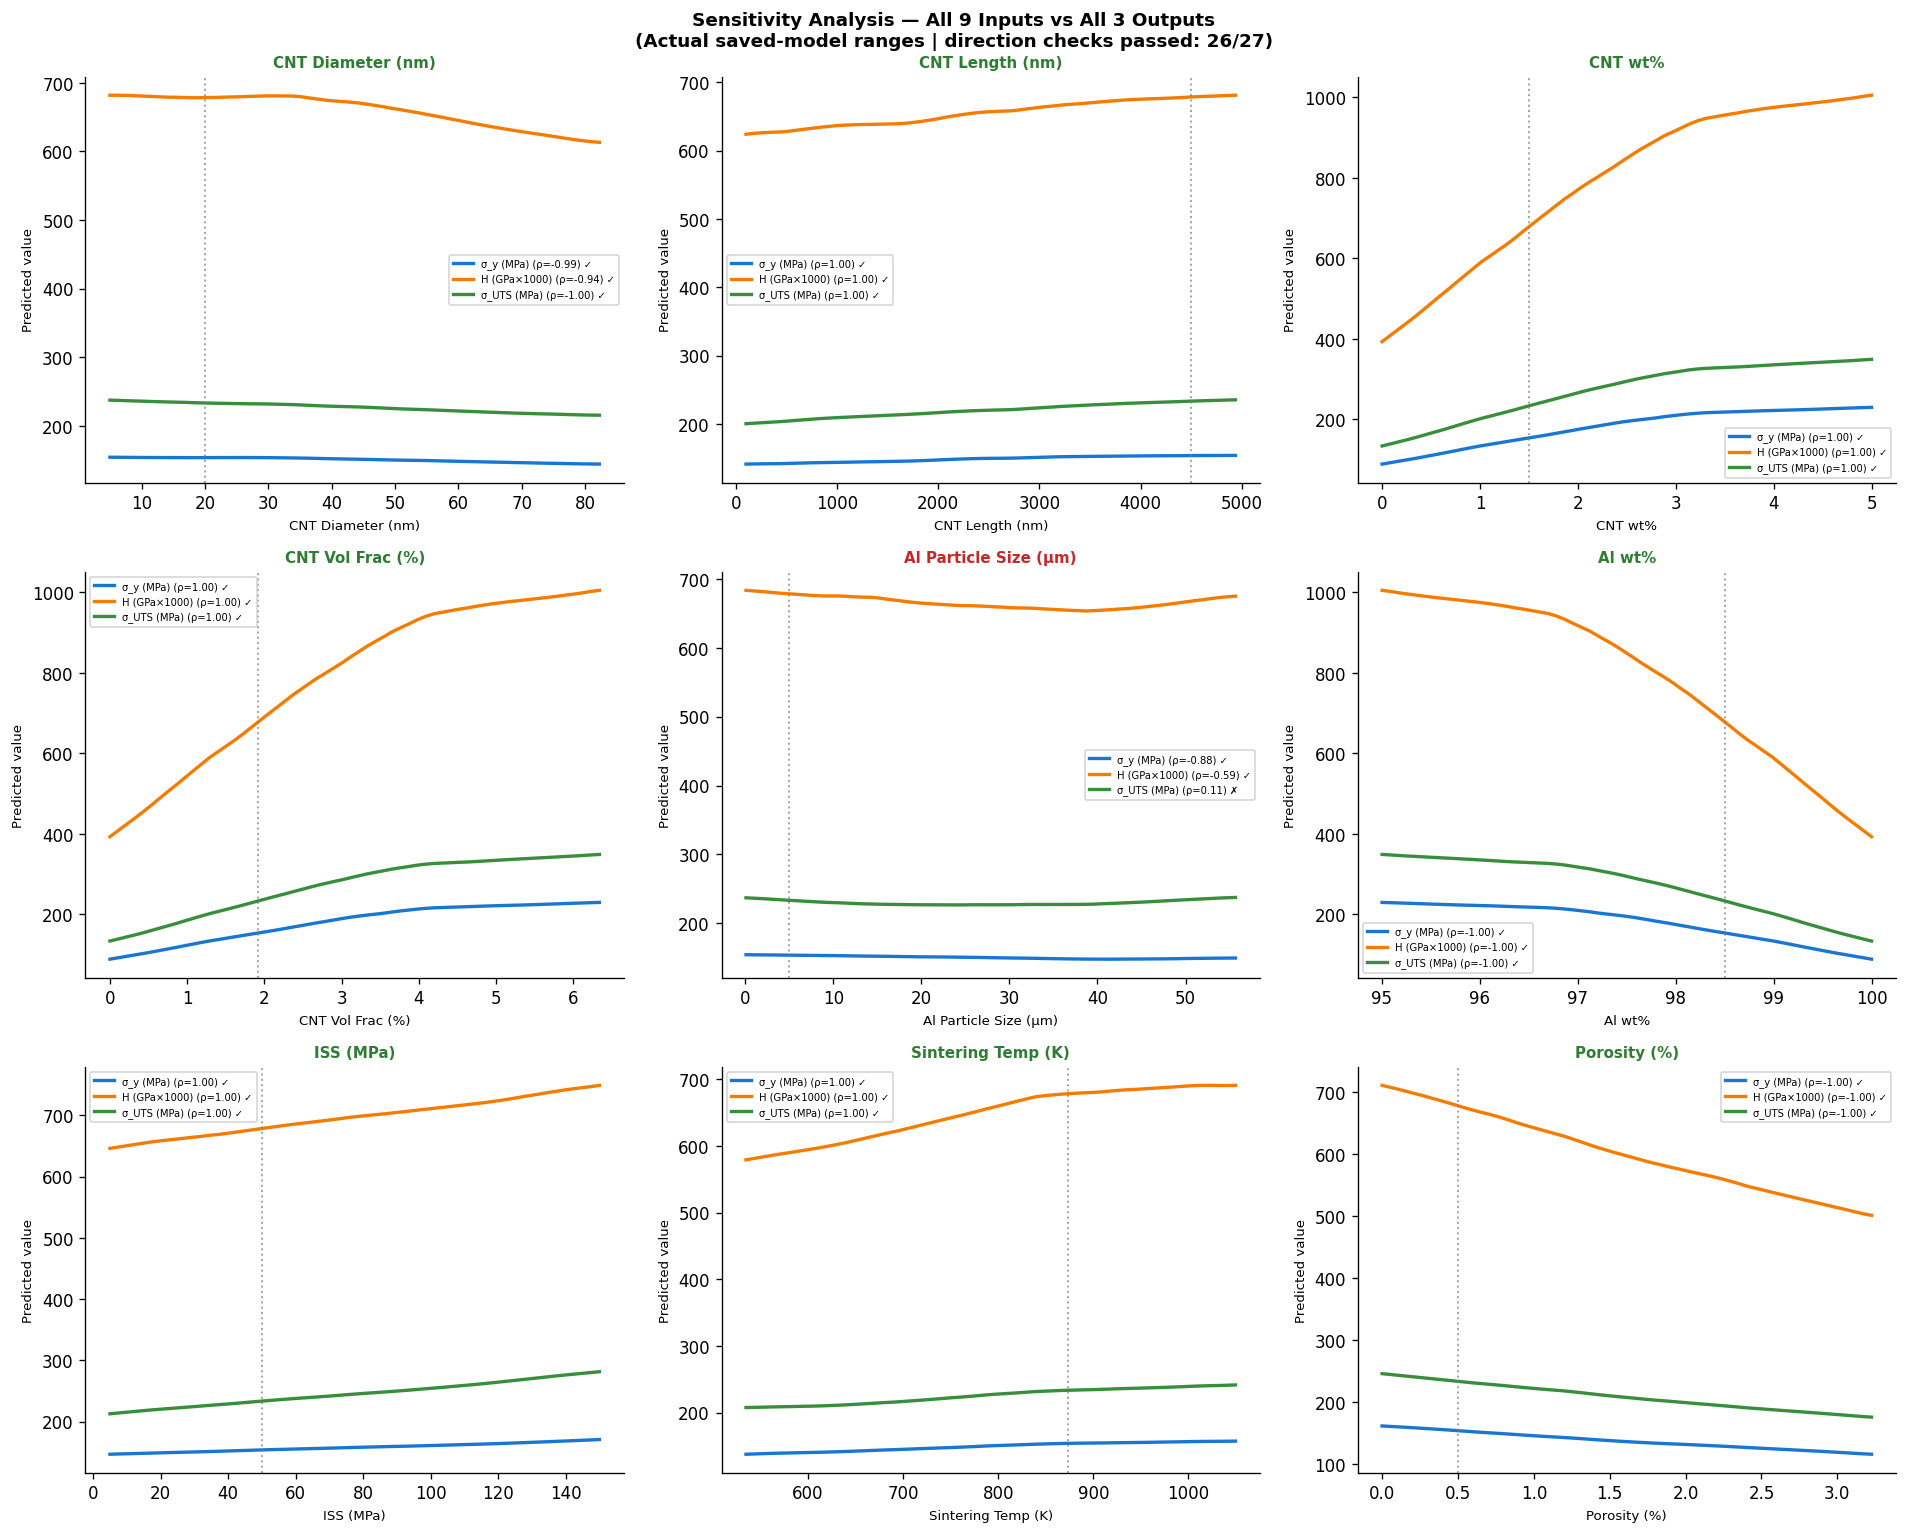

✓ Saved ui_outputs/sensitivity_full_grid.png
✓ Sensitivity direction checks passed: 26/27
✓ Saved ui_outputs/sensitivity_relation_checks.csv


In [ ]:
# Full 9×3 sensitivity grid — hold all inputs at my_sample, vary one at a time
N_POINTS = 60

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

feat_meta = {
    'CNT_d_nm':            dict(label='CNT Diameter (nm)',       expected={'sigma_y_MPa':'↓','Hardness_GPa':'↓','sigma_UTS_MPa':'↓'}),
    'CNT_l_nm':            dict(label='CNT Length (nm)',         expected={'sigma_y_MPa':'↑','Hardness_GPa':'↑','sigma_UTS_MPa':'↑'}),
    'CNT_wt_pct':          dict(label='CNT wt%',                 expected={'sigma_y_MPa':'↑','Hardness_GPa':'↑','sigma_UTS_MPa':'↑'}),
    'CNT_vol_frac':        dict(label='CNT Vol Frac (%)',        expected={'sigma_y_MPa':'↑','Hardness_GPa':'↑','sigma_UTS_MPa':'↑'}),
    'Al_particle_size_um': dict(label='Al Particle Size (μm)',   expected={'sigma_y_MPa':'↓','Hardness_GPa':'↓','sigma_UTS_MPa':'↓'}),
    'Al_wt_pct':           dict(label='Al wt%',                  expected={'sigma_y_MPa':'↓','Hardness_GPa':'↓','sigma_UTS_MPa':'↓'}),
    'ISS_MPa':             dict(label='ISS (MPa)',               expected={'sigma_y_MPa':'↑','Hardness_GPa':'↑','sigma_UTS_MPa':'↑'}),
    'Sinter_T_K':          dict(label='Sintering Temp (K)',      expected={'sigma_y_MPa':'↑','Hardness_GPa':'↑','sigma_UTS_MPa':'↑'}),
    'Porosity_pct':        dict(label='Porosity (%)',            expected={'sigma_y_MPa':'↓','Hardness_GPa':'↓','sigma_UTS_MPa':'↓'}),
}

target_colors = {'sigma_y_MPa':'#1976D2','Hardness_GPa':'#F57C00','sigma_UTS_MPa':'#388E3C'}
target_labels = {'sigma_y_MPa':'σ_y (MPa)','Hardness_GPa':'H (GPa×1000)','sigma_UTS_MPa':'σ_UTS (MPa)'}

check_rows = []
for ax, (feat, info) in zip(axes, feat_meta.items()):
    lo, hi = feat_ranges[feat]
    x_vals = np.linspace(lo, hi, N_POINTS)

    all_ok = True
    for t_col, t_label in target_labels.items():
        ys = []
        for v in x_vals:
            inp = my_sample.copy()
            inp[feat] = float(v)

            # The latest training data uses an exact composition manifold:
            # Al_wt = 100-CNT_wt and CNT_vol_frac is density-derived from CNT_wt.
            if feat == 'CNT_wt_pct':
                inp['Al_wt_pct'] = 100.0 - float(v)
                inp['CNT_vol_frac'] = cnt_wt_to_vf(float(v))
            elif feat == 'Al_wt_pct':
                cnt_wt = 100.0 - float(v)
                inp['CNT_wt_pct'] = cnt_wt
                inp['CNT_vol_frac'] = cnt_wt_to_vf(cnt_wt)
            elif feat == 'CNT_vol_frac':
                cnt_wt = cnt_vf_to_wt(float(v))
                inp['CNT_wt_pct'] = cnt_wt
                inp['Al_wt_pct'] = 100.0 - cnt_wt

            r_s = predict(inp, warn_range=False)
            y_val = r_s[t_col]
            if t_col == 'Hardness_GPa':
                y_val *= 1000
            ys.append(y_val)

        r_corr, p_corr = spearmanr(x_vals, ys)
        exp_dir = info['expected'][t_col]
        sign_ok = (r_corr > 0) if exp_dir == '↑' else (r_corr < 0)
        ok = bool(np.isfinite(r_corr) and sign_ok and abs(r_corr) >= 0.01 and p_corr < 0.05)
        all_ok = all_ok and ok
        check_rows.append({
            'feature': feat, 'target': t_col, 'expected': exp_dir,
            'spearman_r': float(r_corr) if np.isfinite(r_corr) else np.nan,
            'p_value': float(p_corr) if np.isfinite(p_corr) else np.nan,
            'passed': ok
        })

        ax.plot(x_vals, ys, color=target_colors[t_col], linewidth=2.0,
                label=f'{t_label} (ρ={r_corr:.2f}) {"✓" if ok else "✗"}')

    ax.axvline(my_sample[feat], color='grey', linestyle=':', linewidth=1.2, alpha=0.7)
    ax.set_xlabel(info['label'], fontsize=8)
    ax.set_ylabel('Predicted value', fontsize=8)
    ax.set_title(info['label'], fontsize=9, fontweight='bold',
                 color='#2e7d32' if all_ok else '#c62828')
    ax.legend(fontsize=6, loc='best')
    ax.spines[['top','right']].set_visible(False)

sensitivity_checks = pd.DataFrame(check_rows)
sensitivity_checks.to_csv('ui_outputs/sensitivity_relation_checks.csv', index=False)
passed = int(sensitivity_checks['passed'].sum())
total = len(sensitivity_checks)

plt.suptitle('Sensitivity Analysis — All 9 Inputs vs All 3 Outputs\n'
             f'(Actual saved-model ranges | direction checks passed: {passed}/{total})',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('ui_outputs/sensitivity_full_grid.png', bbox_inches='tight')
plt.show()
print(f'✓ Saved ui_outputs/sensitivity_full_grid.png')
print(f'✓ Sensitivity direction checks passed: {passed}/{total}')
print('✓ Saved ui_outputs/sensitivity_relation_checks.csv')

---
## STEP 9 — Download All Outputs

In [ ]:
print(f'Hardness/yield calibration factor C_HY: {hardness_yield_factor:.4f}')
print('Files generated in ui_outputs/:')
for f in sorted(os.listdir('ui_outputs')):
    sz = os.path.getsize(f'ui_outputs/{f}')
    print(f'  {f:<45}  {sz/1024:.1f} KB')

if IN_COLAB:
    import zipfile
    with zipfile.ZipFile('CNT_AL_UI_Outputs.zip', 'w') as zf:
        for f in os.listdir('ui_outputs'):
            zf.write(f'ui_outputs/{f}', f)
    files.download('CNT_AL_UI_Outputs.zip')
    print('\n✓ Downloading CNT_AL_UI_Outputs.zip ...')

Hardness/yield calibration factor C_HY: 4.2730
Files generated in ui_outputs/:
  batch_input_heatmap.png                        70.5 KB
  batch_predictions.csv                          0.8 KB
  batch_predictions_plot.png                     64.7 KB
  normalisation_parameters.csv                   0.7 KB
  prediction_result.png                          94.4 KB
  sensitivity_full_grid.png                      277.4 KB
  sensitivity_relation_checks.csv                1.3 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Downloading CNT_AL_UI_Outputs.zip ...
